# Cellule 1 — Imports et authentification Hugging Face

Cette cellule importe toutes les bibliothèques nécessaires au projet.

Les principales bibliothèques utilisées sont :

- **NumPy** : manipulation des tableaux numériques ;
- **Matplotlib** : génération des graphiques ;
- **PIL (Pillow)** : lecture et traitement des images ;
- **Scikit-learn** : entraînement du modèle de Machine Learning ;
- **Joblib** : sauvegarde des modèles entraînés ;
- **JSON, Path et Datetime** : gestion des expériences et sauvegarde des résultats ;
- **Datasets** : chargement du dataset depuis Hugging Face ;
- **Dotenv** : récupération sécurisée du token Hugging Face.

Le dataset étant privé, un token d'authentification est récupéré depuis un fichier `.env`.

```python
hf_token = os.getenv("KEY_HUGGING_FACE")
```

Cette méthode évite d'exposer le token directement dans le code ou sur GitHub.

Une vérification est effectuée afin de s'assurer que le token est bien chargé avant la suite de l'exécution.

In [ ]:
# ===============================
# Cellule 1 — Imports & Token
# ===============================

import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib


import json
from pathlib import Path
from datetime import datetime


from datasets import load_dataset
from PIL import Image

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Charger les variables d'environnement (.env)
load_dotenv()

# Récupérer le token Hugging Face
hf_token = os.getenv("KEY_HUGGING_FACE")

if hf_token is None:
    raise ValueError("HF token not found. Vérifie ton fichier .env")

print("Token loaded successfully!")

Token loaded successfully!


# Cellule 2 — Chargement du dataset

Cette cellule charge le dataset privé :

```text
PAR8/chest-xray-pneumonia
```

Le dataset est téléchargé depuis Hugging Face grâce au token récupéré précédemment.

Il est composé de trois ensembles :

- **Train** : utilisé pour entraîner le modèle ;
- **Validation** : utilisé pour évaluer le modèle pendant les expérimentations ;
- **Test** : utilisé pour l'évaluation finale.

Les classes présentes dans le dataset sont :

| Label | Classe |
|---------|---------|
| 0 | NORMAL |
| 1 | BACTERIA |
| 2 | VIRUS |

Après chargement, le nombre d'images de chaque split est affiché afin de vérifier que les données ont bien été récupérées.

In [16]:
# ===============================
# Cellule 2 — Load Dataset
# ===============================

print("Loading dataset from HuggingFace...")

dataset = load_dataset(
    "PAR8/chest-xray-pneumonia",
    token=hf_token
)

train_data = dataset["train"]
val_data   = dataset["validation"]
test_data  = dataset["test"]

print("\nDataset loaded successfully!")
print(f"Train: {len(train_data)} images")
print(f"Validation: {len(val_data)} images")
print(f"Test: {len(test_data)} images")

Loading dataset from HuggingFace...

Dataset loaded successfully!
Train: 4705 images
Validation: 522 images
Test: 624 images


# Cellule 3 — Prétraitement des images

Cette cellule transforme les images du dataset en vecteurs numériques exploitables par une Logistic Regression.

Les étapes de prétraitement sont les suivantes :

### 1. Conversion en niveaux de gris

```python
img.convert("L")
```

La couleur n'étant pas nécessaire pour analyser une radiographie, les images sont converties en niveaux de gris.

---

### 2. Redimensionnement

```python
img.resize((128,128))
```

Toutes les images sont ramenées à la même taille afin de garantir un nombre identique de features.

---

### 3. Normalisation

```python
arr / 255.0
```

Les pixels sont convertis dans l'intervalle :

```text
[0 ; 1]
```

afin d'améliorer la stabilité numérique.

---

### 4. Flatten

```python
arr.flatten()
```

L'image 128×128 est transformée en un vecteur de :

```text
128 × 128 = 16 384 features
```

Chaque pixel devient une variable d'entrée du modèle.

---

La fonction retourne :

- X : matrice des features ;
- y : vecteur des labels.

Les ensembles train, validation et test sont ensuite prétraités séparément.

In [17]:
# ===============================
# Cellule 3 — Preprocessing (images -> features)
# ===============================

IMG_SIZE = (128, 128)
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]  # 0,1,2

def preprocess_split(split):
    """
    Transforme un split HuggingFace en matrices X (features) et y (labels).
    Étapes :
    - Conversion en niveaux de gris
    - Redimensionnement
    - Normalisation [0,1]
    - Flatten en vecteur
    """
    X = []
    y = []

    for example in split:
        img = example["image"]

        # Sécurité : s'assurer que c'est bien une image PIL
        if not isinstance(img, Image.Image):
            continue

        img = img.convert("L")            # grayscale
        img = img.resize(IMG_SIZE)        # resize
        arr = np.array(img, dtype=np.float32) / 255.0

        X.append(arr.flatten())
        y.append(example["label"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y



print("Preprocessing splits...")

X_train, y_train = preprocess_split(train_data)
X_val, y_val     = preprocess_split(val_data)
X_test, y_test   = preprocess_split(test_data)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape, "distribution:", np.unique(y_train, return_counts=True))

print("X_val:", X_val.shape)
print("y_val:", y_val.shape, "distribution:", np.unique(y_val, return_counts=True))

print("X_test:", X_test.shape)
print("y_test:", y_test.shape, "distribution:", np.unique(y_test, return_counts=True))

Preprocessing splits...

Shapes:
X_train: (4705, 16384)
y_train: (4705,) distribution: (array([0, 1, 2]), array([1175, 2362, 1168]))
X_val: (522, 16384)
y_val: (522,) distribution: (array([0, 1, 2]), array([174, 174, 174]))
X_test: (624, 16384)
y_test: (624,) distribution: (array([0, 1, 2]), array([234, 242, 148]))


# Cellule 4 — Standardisation des données

Cette cellule applique une standardisation aux données à l'aide du StandardScaler.

La Logistic Regression étant sensible à l'échelle des variables, il est nécessaire de normaliser les features.

Le StandardScaler transforme les données afin que :

- la moyenne soit proche de 0 ;
- l'écart-type soit proche de 1.

Le scaler est entraîné uniquement sur le train :

```python
scaler.fit_transform(X_train)
```

Puis appliqué sur validation et test :

```python
scaler.transform(X_val)
scaler.transform(X_test)
```

Cette méthode évite toute fuite de données entre les différents ensembles.

In [18]:
# ===============================
# Cellule 4 — StandardScaler
# ===============================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling done!")
print("X_train_s:", X_train_s.shape)

Scaling done!
X_train_s: (4705, 16384)


# Cellule — Système de suivi des expériences

Cette cellule met en place un système de suivi automatique des expériences réalisées.

Un dossier :

```text
result/
```

est créé automatiquement.

À l'intérieur, un fichier :

```text
experiments_logistic_regression.json
```

enregistre l'ensemble des expérimentations.

Chaque expérience sauvegarde :

- la date ;
- l'identifiant ;
- les hyperparamètres utilisés ;
- les scores de validation ;
- les scores de test ;
- le dossier contenant les graphiques.

Ce système permet de conserver un historique complet des essais réalisés et facilite la comparaison des différentes configurations.

In [19]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(list(Path(".").iterdir()))

Current working directory:
/Users/williamleite/Documents/projetepitech/pneumonia_logreg/pneumonia_logistic_regression

Files here:
[PosixPath('train_final.ipynb'), PosixPath('models')]


In [20]:
import os
print(os.getcwd())

/Users/williamleite/Documents/projetepitech/pneumonia_logreg/pneumonia_logistic_regression


In [21]:
# ===============================
# Cellule — Experiment Logger
# ===============================

RESULT_DIR = Path("../results/logistic_regression")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

JSON_PATH = RESULT_DIR / "results_history.json"

def load_experiments():
    if JSON_PATH.exists():
        with open(JSON_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return []

def get_next_experiment_id():
    experiments = load_experiments()
    return len(experiments) + 1

def save_experiment(config, scores_test, scores_val=None):
    experiments = load_experiments()
    experiment_id = get_next_experiment_id()

    exp_dir = RESULT_DIR / f"experiment_{experiment_id}"
    exp_dir.mkdir(exist_ok=True)

    experiment = {
        "experiment_id": experiment_id,
        "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": "LogisticRegression",
        "config": config,
        "scores_validation": scores_val,
        "scores_test": scores_test,
        "result_folder": str(exp_dir)
    }

    experiments.append(experiment)

    with open(JSON_PATH, "w", encoding="utf-8") as f:
        json.dump(experiments, f, indent=4)

    print(f"Experiment {experiment_id} saved in JSON.")
    return experiment_id, exp_dir

# Cellule — Validation croisée (Cross Validation)

Cette cellule réalise une validation croisée stratifiée sur l'ensemble d'entraînement.

L'objectif est d'évaluer la robustesse du modèle avant l'évaluation finale.

Une validation croisée à 3 plis est utilisée :

```python
StratifiedKFold(n_splits=3)
```

À chaque itération :

- une partie du train sert à l'entraînement ;
- une autre partie sert à la validation.

La méthode est répétée trois fois avec des découpages différents.

Le score utilisé est :

```python
F1 Macro
```

car il est particulièrement adapté aux problèmes multi-classes.

À la fin, la moyenne et l'écart-type des scores sont calculés afin d'estimer la stabilité du modèle.

In [22]:
# ===============================
# Cellule — Cross Validation
# ===============================

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_model = LogisticRegression(
    max_iter=8000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
    C=0.01,
    penalty="l2"
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Running 3-Fold Cross Validation...")

cv_scores = cross_val_score(
    cv_model,
    X_train_s,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1-macro scores:", cv_scores)
print("Mean F1-macro:", cv_scores.mean())
print("Std F1-macro:", cv_scores.std())

Running 3-Fold Cross Validation...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


F1-macro scores: [0.71573346 0.73845768 0.73920103]
Mean F1-macro: 0.7311307225534329
Std F1-macro: 0.010891739029088774


# Cellule 5 — Entraînement de la Logistic Regression

Cette cellule entraîne le modèle principal de classification.

Le modèle utilisé est :

```python
LogisticRegression()
```

adapté à une classification multi-classe.

Les paramètres utilisés sont :

- solver = saga ;
- class_weight = balanced ;
- penalty = l2 ;
- C = 0.01 ;
- max_iter = 8000.

La valeur :

```python
C = 0.01
```

provient d'une phase d'optimisation réalisée précédemment avec GridSearch.

Une faible valeur de C implique une régularisation plus forte, ce qui limite le surapprentissage.

Le modèle apprend à associer les vecteurs de pixels aux trois classes :

- NORMAL ;
- BACTERIA ;
- VIRUS.

L'entraînement est réalisé sur l'ensemble train standardisé.

In [23]:
# ===============================
# Cellule 5 — Logistic Regression (multiclass) avec le meilleur C
# ===============================

model = LogisticRegression(
    max_iter=8000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
    C=0.01,        # meilleur paramètre trouvé avec GridSearch
    penalty="l2"
)

print("Training Logistic Regression (C=0.01)...")

model.fit(X_train_s, y_train)

print("Training done!")

Training Logistic Regression (C=0.01)...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done!


# Cellule 6 — Évaluation du modèle

Cette cellule évalue les performances du modèle.

Les prédictions sont obtenues à l'aide de :

```python
model.predict()
```

Les probabilités sont obtenues grâce à :

```python
model.predict_proba()
```

Les métriques calculées sont :

- Accuracy ;
- Precision ;
- Recall ;
- F1-score ;
- ROC-AUC.

Les métriques sont calculées en moyenne macro afin de donner le même poids à chaque classe.

Une matrice de confusion est également générée afin d'analyser les erreurs de classification.

L'évaluation est effectuée sur :

- le jeu de validation ;
- le jeu de test.

In [24]:
# ===============================
# Cellule 6 — Evaluation (metrics + report)
# ===============================

def evaluate_multiclass(name, model, Xs, y_true, class_names):
    y_pred = model.predict(Xs)
    y_proba = model.predict_proba(Xs)  # shape (n,3)

    # Metrics (macro = moyenne non pondérée sur les classes)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # ROC-AUC multi-classe (OVR)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")

    print(f"\n===== {name} =====")
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names, digits=4))

    scores = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }
    print("\nScores:")
    for k, v in scores.items():
        print(f"- {k}: {v:.4f}")

    return scores

scores_val = evaluate_multiclass("VALIDATION", model, X_val_s, y_val, CLASS_NAMES)
scores_test = evaluate_multiclass("TEST", model, X_test_s, y_test, CLASS_NAMES)


===== VALIDATION =====
Confusion matrix:
 [[163   4   7]
 [  6 129  39]
 [ 10  57 107]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9106    0.9368    0.9235       174
    BACTERIA     0.6789    0.7414    0.7088       174
       VIRUS     0.6993    0.6149    0.6544       174

    accuracy                         0.7644       522
   macro avg     0.7630    0.7644    0.7622       522
weighted avg     0.7630    0.7644    0.7622       522


Scores:
- Accuracy: 0.7644
- Precision: 0.7630
- Recall: 0.7644
- F1-score: 0.7622
- ROC-AUC: 0.9035

===== TEST =====
Confusion matrix:
 [[ 95  51  88]
 [  3 212  27]
 [  4  53  91]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9314    0.4060    0.5655       234
    BACTERIA     0.6709    0.8760    0.7599       242
       VIRUS     0.4417    0.6149    0.5141       148

    accuracy                         0.6378       624
   macro avg     0.6813

Cellule 7 — Graphique barres en %

Cette cellule définit une fonction permettant d’afficher les scores sous forme de graphique en barres.

Les scores sont affichés en pourcentage :
Accuracy, Precision, Recall, F1-score, ROC-AUC

La fonction peut aussi sauvegarder automatiquement le graphique dans le dossier result.

Exemple :
save_path=exp_dir_pixels / "logreg_pixels_test_scores.png"
Cela permet de conserver les résultats de chaque expérience.

In [25]:
# ===============================
# Cellule 7 — Bar chart (%) + Save
# ===============================

def plot_scores(scores, title, save_path=None):
    labels = list(scores.keys())
    values = [scores[k] * 100 for k in labels]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, values)

    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 1,
            f"{val:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Graph saved: {save_path}")

    plt.show()

# Cellule — Sauvegarde de l'expérience (Pixels)

Cette cellule enregistre les résultats obtenus avec la Logistic Regression utilisant les pixels bruts.

Les informations sauvegardées comprennent :

- les hyperparamètres ;
- les scores de validation ;
- les scores de test ;
- les informations de prétraitement.

Chaque expérience reçoit un identifiant unique.

Les résultats sont enregistrés dans :

```text
result/experiment_X/
```

afin de conserver une trace complète des expérimentations.

Experiment 3 saved in JSON.
Graph saved: ../results/logistic_regression/experiment_3/logreg_pixels_test_scores.png


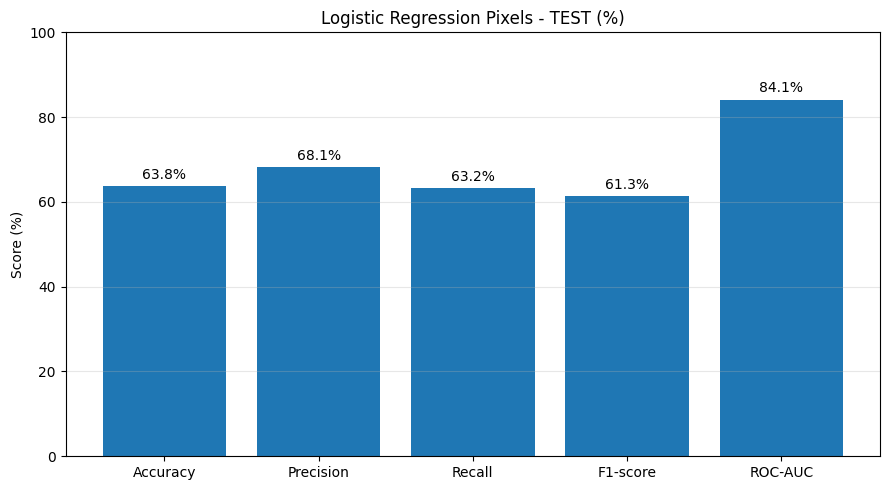

In [26]:
# ===============================
# Save experiment — Pixels
# ===============================

config_pixels = {
    "image_size": IMG_SIZE,
    "features": "raw_pixels_flatten",
    "scaler": "StandardScaler",
    "pca": False,
    "max_iter": 8000,
    "solver": "saga",
    "multi_class": "multinomial",
    "class_weight": "balanced",
    "C": 0.01,
    "penalty": "l2"
}

experiment_id_pixels, exp_dir_pixels = save_experiment(
    config=config_pixels,
    scores_val=scores_val,
    scores_test=scores_test
)

plot_scores(
    scores_test,
    "Logistic Regression Pixels - TEST (%)",
    save_path=exp_dir_pixels / "logreg_pixels_test_scores.png"
)

# Cellule — Analyse de l'importance des features

Cette cellule permet d'interpréter le modèle entraîné.

Dans une Logistic Regression, l'importance des features est directement liée aux coefficients appris.

Comme chaque feature correspond à un pixel de l'image, les coefficients peuvent être retransformés en image 128×128.

On obtient ainsi une carte d'importance pour chacune des classes :

- NORMAL ;
- BACTERIA ;
- VIRUS.

Cette visualisation permet d'identifier les zones de la radiographie ayant le plus d'influence sur les prédictions du modèle.

Saved: ../results/logistic_regression/experiment_3/feature_importance_NORMAL.png


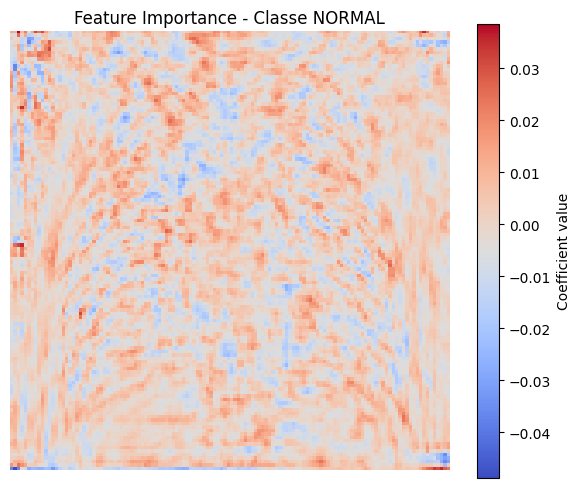

Saved: ../results/logistic_regression/experiment_3/feature_importance_BACTERIA.png


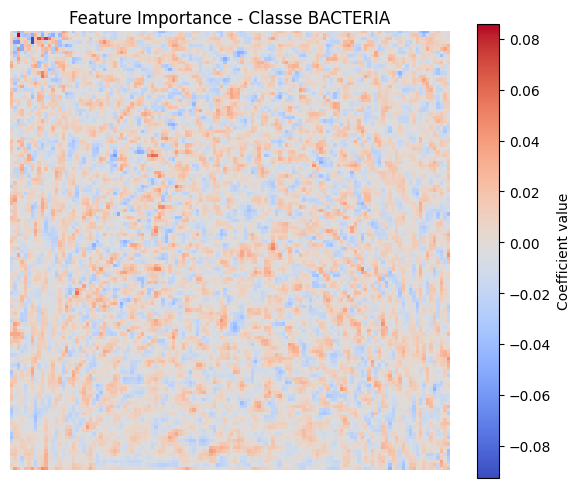

Saved: ../results/logistic_regression/experiment_3/feature_importance_VIRUS.png


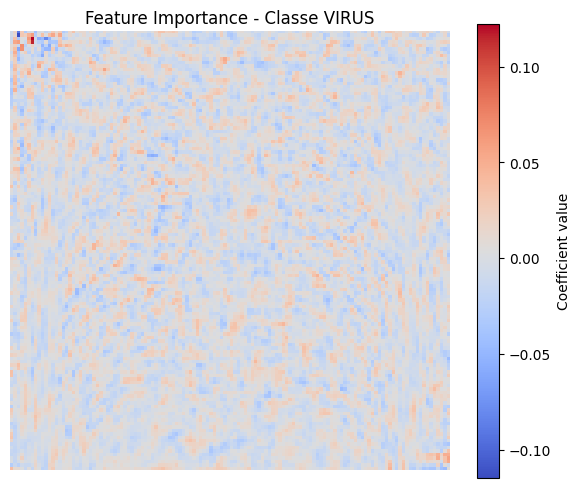

In [28]:
# ===============================
# Cellule — Feature Importance + Save
# ===============================

def save_logreg_feature_importance(model, img_size, class_names, save_dir):
    coefs = model.coef_

    for i, class_name in enumerate(class_names):
        importance_map = coefs[i].reshape(img_size)

        plt.figure(figsize=(6, 5))
        plt.imshow(importance_map, cmap="coolwarm")
        plt.colorbar(label="Coefficient value")
        plt.title(f"Feature Importance - Classe {class_name}")
        plt.axis("off")
        plt.tight_layout()

        save_path = save_dir / f"feature_importance_{class_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

        plt.show()

save_logreg_feature_importance(
    model=model,
    img_size=IMG_SIZE,
    class_names=CLASS_NAMES,
    save_dir=exp_dir_pixels
)

# Cellule 8 — PCA + Logistic Regression

Cette cellule entraîne une seconde version du modèle utilisant une réduction de dimension.

La méthode PCA (Principal Component Analysis) est appliquée afin de réduire le nombre de features.

L'objectif est de :

- réduire le bruit ;
- diminuer la dimension des données ;
- limiter le surapprentissage ;
- accélérer l'entraînement.

Le PCA conserve :

```python
95 % de la variance
```

avant d'entraîner une nouvelle Logistic Regression.

Les performances obtenues sont ensuite comparées avec celles du modèle utilisant les pixels bruts.

PCA dims: 16384 -> 383
Training Logistic Regression + PCA...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done!

===== VALIDATION (PCA) =====
Confusion matrix:
 [[164   2   8]
 [  2 122  50]
 [  8  57 109]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9425    0.9425    0.9425       174
    BACTERIA     0.6740    0.7011    0.6873       174
       VIRUS     0.6527    0.6264    0.6393       174

    accuracy                         0.7567       522
   macro avg     0.7564    0.7567    0.7564       522
weighted avg     0.7564    0.7567    0.7564       522


Scores:
- Accuracy: 0.7567
- Precision: 0.7564
- Recall: 0.7567
- F1-score: 0.7564
- ROC-AUC: 0.9031

===== TEST (PCA) =====
Confusion matrix:
 [[ 93  30 111]
 [  3 216  23]
 [  3  32 113]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9394    0.3974    0.5586       234
    BACTERIA     0.7770    0.8926    0.8308       242
       VIRUS     0.4575    0.7635    0.5722       148

    accuracy                         0.6763       

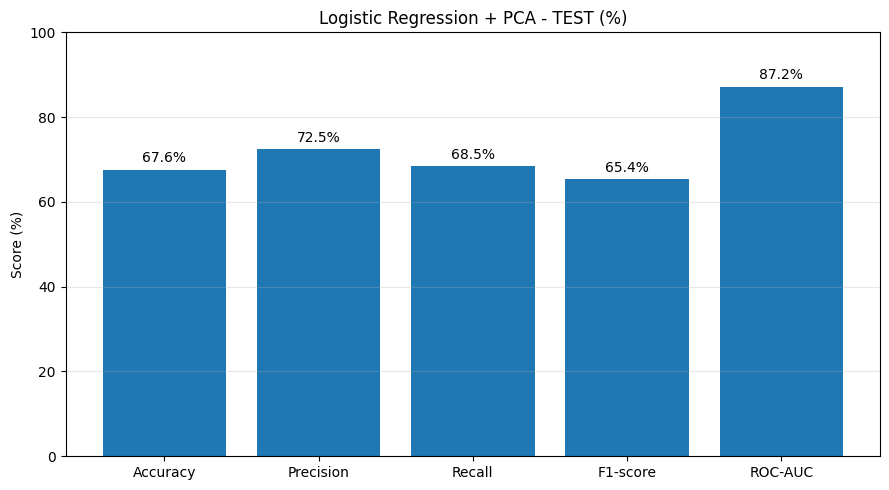

In [29]:
# ===============================
# Cellule 8 — PCA + Logistic Regression + Save experiment
# ===============================

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_s)
X_val_pca   = pca.transform(X_val_s)
X_test_pca  = pca.transform(X_test_s)

print("PCA dims:", X_train_s.shape[1], "->", X_train_pca.shape[1])

model_pca = LogisticRegression(
    max_iter=8000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
    C=0.01,
    penalty="l2"
)

print("Training Logistic Regression + PCA...")
model_pca.fit(X_train_pca, y_train)
print("Training done!")

scores_val_pca = evaluate_multiclass("VALIDATION (PCA)", model_pca, X_val_pca, y_val, CLASS_NAMES)
scores_test_pca = evaluate_multiclass("TEST (PCA)", model_pca, X_test_pca, y_test, CLASS_NAMES)

config_pca = {
    "image_size": IMG_SIZE,
    "features": "raw_pixels_flatten",
    "scaler": "StandardScaler",
    "pca": True,
    "pca_n_components": 0.95,
    "pca_output_dimensions": X_train_pca.shape[1],
    "max_iter": 8000,
    "solver": "saga",
    "multi_class": "multinomial",
    "class_weight": "balanced",
    "C": 0.01,
    "penalty": "l2"
}

experiment_id_pca, exp_dir_pca = save_experiment(
    config=config_pca,
    scores_val=scores_val_pca,
    scores_test=scores_test_pca
)

plot_scores(
    scores_test_pca,
    "Logistic Regression + PCA - TEST (%)",
    save_path=exp_dir_pca / "logreg_pca_test_scores.png"
)

# Cellule 9 — Comparaison finale et sauvegarde des modèles

Cette cellule compare les performances des deux approches :

1. Logistic Regression utilisant les pixels bruts ;
2. Logistic Regression utilisant le PCA.

Les métriques comparées sont :

- Accuracy ;
- Precision ;
- Recall ;
- F1-score ;
- ROC-AUC.

Un graphique comparatif est généré afin de visualiser rapidement les différences de performances.

Enfin, les objets nécessaires à la réutilisation du modèle sont sauvegardés :

- modèle Logistic Regression ;
- modèle Logistic Regression + PCA ;
- StandardScaler ;
- PCA.

La sauvegarde est réalisée avec Joblib afin de pouvoir réutiliser les modèles sans devoir les réentraîner.

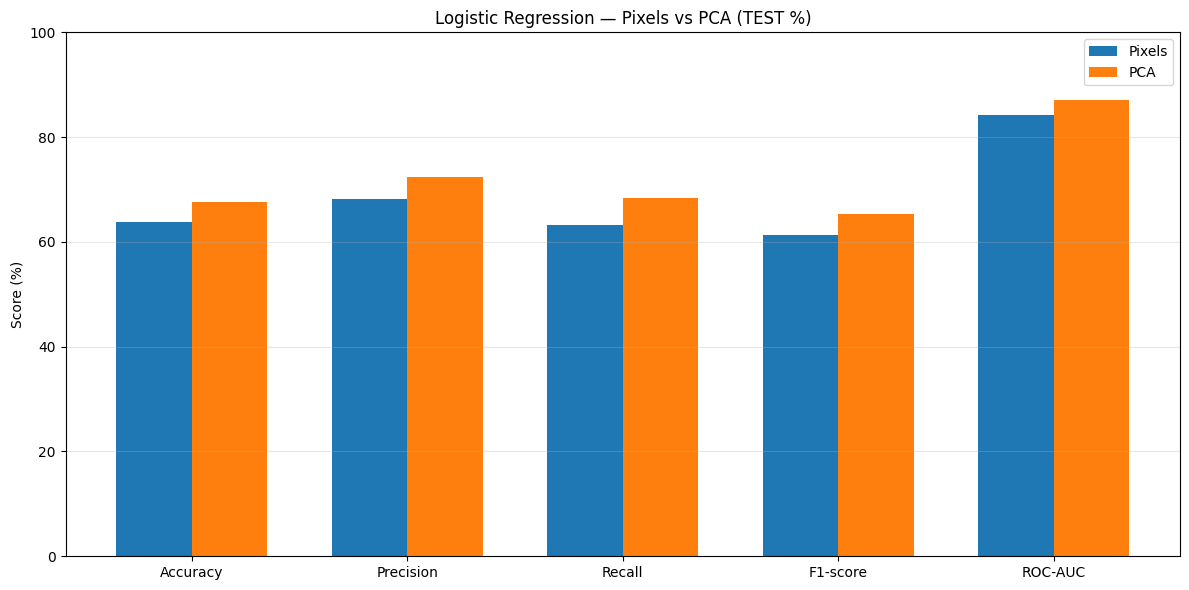

Saved models in pneumonia_logistic_regression/models/


In [30]:
# ===============================
# Cellule 9 — Compare + Save
# ===============================

def compare_models_bar(models_scores, title="Comparaison modèles (TEST %)"):
    metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
    names = list(models_scores.keys())

    x = np.arange(len(metrics))
    width = 0.35 if len(names) == 2 else 0.25

    plt.figure(figsize=(12, 6))
    for i, name in enumerate(names):
        vals = [models_scores[name][m] * 100 for m in metrics]
        plt.bar(x + i * width, vals, width=width, label=name)

    plt.xticks(x + width * (len(names)-1)/2, metrics)
    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_models_bar(
    {"Pixels": scores_test, "PCA": scores_test_pca},
    "Logistic Regression — Pixels vs PCA (TEST %)"
)

# ===============================
# Sauvegarde des modèles
# ===============================

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "logreg_3classes_pixels.pkl")
joblib.dump(model_pca, MODEL_DIR / "logreg_3classes_pca.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(pca, MODEL_DIR / "pca.pkl")

print("Saved models in pneumonia_logistic_regression/models/")